# Analyse de la dérive des données en production — modèle `scoring_credit` v1

**Contexte.** L'API de scoring « Prêt à Dépenser » journalise chaque prédiction dans PostgreSQL
(score, décision, latences ; entrées complètes pour un échantillon). Ce notebook réalise
l'**analyse automatique** de ces données : dérive des données (data drift), dérive des scores,
estimation de la performance sans labels, confrontation aux labels différés, calibrage du seuil
et points de vigilance opérationnels.

**Méthode (tout est mesurable et reproductible).**

| Question | Méthode | Seuil de décision |
|---|---|---|
| La distribution des entrées a-t-elle changé ? | PSI (10 quantiles de la référence, bin NaN) + test de Kolmogorov-Smirnov | PSI < 0,10 stable · 0,10–0,25 à surveiller · ≥ 0,25 dérive ; KS : p < 0,01 / n_colonnes (Bonferroni) |
| Le jeu de données dans son ensemble dérive-t-il ? | part de colonnes en alerte PSI | > 30 % des colonnes et ≥ 200 lignes |
| Les scores / décisions ont-ils changé ? | PSI du score, taux de refus + IC binomial de Wilson vs 32,1 % | IC n'incluant pas la référence |
| Le modèle reste-t-il performant sans labels ? | CBPE simplifié : espérances de FN/FP à partir des probabilités calibrées (isotonique sur la référence) | écart de coût attendu vs 0,501 |
| … et avec les labels différés ? | AUC, coût métier `(10·FN + FP)/n`, rappel réalisés | comparés à l'estimation |
| Le seuil 0,48 est-il toujours optimal ? | courbe coût / seuil sur référence et sur production labellisée | minimum de coût |

**Référence** : 20 000 dossiers de X_test du P6 (split identique au notebook 4 : `test_size=0.2,
stratify, random_state=42`), avec leurs 38 variables, `TARGET` et la probabilité du modèle.
**Production** : trafic simulé par `simulation/simulate_traffic.py` (dossiers réels de X_test,
disjoints de la référence), avec des scénarios marqués par l'en-tête `X-Scenario` :
`normal`, `drift_ext_source` (scores externes −0,15), `drift_credit` (montants ×1,5),
`drift_missing` (EXT_SOURCE_1/3 absents), `invalid` (5 % de dossiers invalides → 422).

In [1]:
import os, sys, json, warnings
from pathlib import Path
from datetime import datetime, timedelta, UTC
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))
if not os.environ.get("DATABASE_URL") and (ROOT / ".env").exists():
    for line in (ROOT / ".env").read_text().splitlines():
        if line.startswith("DATABASE_URL="):
            os.environ["DATABASE_URL"] = line.split("=", 1)[1].strip()
DB_URL = os.environ["DATABASE_URL"]

from scoring_api.monitoring.reference import load_reference, load_reference_metrics
from scoring_api.monitoring.production import load_predictions, expand_inputs, load_errors
from scoring_api.monitoring.drift import drift_table, dataset_summary, evidently_report, refusal_rate_ci, PSI_WARN, PSI_ALERT, MONITORED_COLUMNS
from scoring_api.monitoring.performance import reliability_table, expected_calibration_error, fit_calibrator, expected_metrics, realized_metrics
from scoring_api.monitoring.threshold import cost_curve, optimal_threshold, business_cost
from scoring_api.features.spec import ENGINEERED, RAW_FIELDS

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
reference = load_reference(); ref_metrics = load_reference_metrics()
THRESHOLD = ref_metrics["threshold"]
print(f"Référence : {reference.shape}  |  seuil {THRESHOLD:.2f}  |  AUC {ref_metrics['auc']:.3f}  |  coût {ref_metrics['business_cost']:.3f}  |  refus {ref_metrics['refusal_rate']:.1%}")

Référence : (20000, 43)  |  seuil 0.48  |  AUC 0.778  |  coût 0.501  |  refus 32.1%


## 1. Données de production stockées (PostgreSQL)

In [2]:
preds = load_predictions(DB_URL)
errors = load_errors(DB_URL, limit=10_000)
preds["scenario"] = preds["scenario"].fillna("(non marqué)")
print(f"{len(preds)} prédictions, {int(preds['sampled'].sum())} avec entrées complètes ({preds['sampled'].mean():.0%}), "
      f"{preds['target'].notna().sum()} labellisées ; {len(errors)} erreurs API")
resume = preds.groupby("scenario").agg(dossiers=("proba_defaut", "size"), echantillonnes=("sampled", "sum"),
    labellises=("target", lambda s: s.notna().sum()), score_moyen=("proba_defaut", "mean"),
    taux_refus=("decision", lambda s: (s == "Refusé").mean()), p99_latence_ms=("latency_total_ms", lambda s: s.quantile(0.99)))
resume.round(3)

6561 prédictions, 6334 avec entrées complètes (97%), 6260 labellisées ; 42 erreurs API


,dossiers,echantillonnes,labellises,score_moyen,taux_refus,p99_latence_ms
scenario,,,,,,
(non marqué),300,73,0,0.200,0.000,0.108
drift_credit,800,800,800,0.381,0.320,1.075
drift_ext_source,800,800,800,0.499,0.528,1.829
drift_missing,800,800,800,0.397,0.334,1.937
drift_young,600,600,600,0.498,0.572,0.995
invalid,760,760,760,0.379,0.299,1.458
normal,2501,2501,2500,0.386,0.325,1.340


> Le stockage (schéma `predictions` / `api_errors` / `prediction_labels`) conserve 100 % des scores
> et latences (ligne légère ≈ 120 octets) et les entrées complètes pour l'échantillon (25 % + zone
> grise + trafic marqué). Les erreurs 422 sont stockées avec le détail Pydantic et le corps reçu.

## 2. Dérive des entrées et des scores, scénario par scénario

In [3]:
scenarios = [s for s in ["normal", "drift_ext_source", "drift_credit", "drift_missing", "invalid"] if s in set(preds["scenario"])]
tables, summaries = {}, {}
for s in scenarios:
    cur = expand_inputs(preds[preds["scenario"] == s])
    tables[s] = drift_table(reference, cur)
    summaries[s] = dataset_summary(tables[s], len(cur))
pd.DataFrame(summaries).T[["n_current", "n_psi_warn", "n_psi_drift", "n_ks_drift", "share_alert", "dataset_drift", "score_psi"]].round(3)

,n_current,n_psi_warn,n_psi_drift,n_ks_drift,share_alert,dataset_drift,score_psi
normal,2501,0,0,0,0.0,False,0.002879
drift_ext_source,800,5,5,5,0.119048,False,0.312439
drift_credit,800,5,4,5,0.119048,False,0.021782
drift_missing,800,3,2,3,0.076923,False,0.012634
invalid,760,0,0,0,0.0,False,0.017586


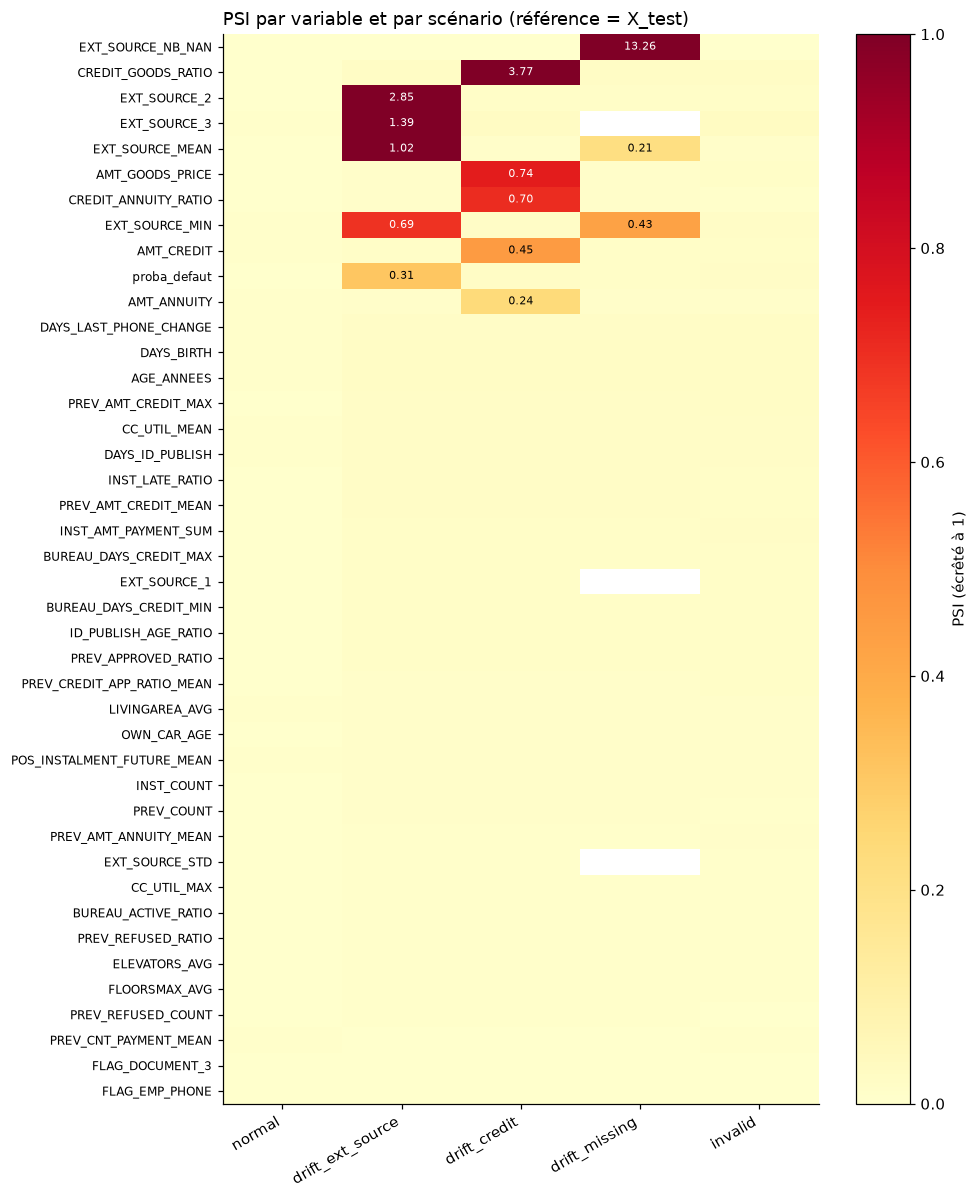

In [4]:
psi_matrix = pd.DataFrame({s: t.set_index("colonne")["psi"] for s, t in tables.items()})
order = psi_matrix.max(axis=1).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 11))
im = ax.imshow(psi_matrix.loc[order].clip(upper=1.0), aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)
ax.set_xticks(range(len(psi_matrix.columns))); ax.set_xticklabels(psi_matrix.columns, rotation=30, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
for i, c in enumerate(order):
    for j, s in enumerate(psi_matrix.columns):
        v = psi_matrix.loc[c, s]
        if v >= PSI_WARN: ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v > 0.5 else "black")
plt.colorbar(im, ax=ax, label="PSI (écrêté à 1)"); ax.set_title("PSI par variable et par scénario (référence = X_test)", loc="left")
plt.tight_layout(); plt.show()

**Lecture.** Chaque scénario ne fait réagir que les variables réellement modifiées et leurs dérivées
(`drift_ext_source` → EXT_SOURCE_2/3, EXT_SOURCE_MEAN/MIN et le **score** ; `drift_credit` →
AMT_CREDIT/ANNUITY/GOODS_PRICE et les ratios ; `drift_missing` → taux de NaN d'EXT_SOURCE_1/3 et
EXT_SOURCE_NB_NAN). Le scénario `normal` reste sous 0,10 partout : pas de faux positif avec 800 lignes.

,colonne,type,psi,statut_psi,ks_stat,ks_p,ks_derive,moy_ref,moy_cur,nan_ref,nan_cur
0,EXT_SOURCE_2,brute,2.8462,dérive,0.3710,0.0000,True,0.5127,0.3690,0.0022,0.0012
1,EXT_SOURCE_3,brute,1.3929,dérive,0.3198,0.0000,True,0.5115,0.3608,0.1988,0.1925
2,EXT_SOURCE_MEAN,dérivée,1.0183,dérive,0.3256,0.0000,True,0.5095,0.3851,0.0006,0.0000
3,EXT_SOURCE_MIN,dérivée,0.6914,dérive,0.2287,0.0000,True,0.3991,0.2744,0.0006,0.0000
4,proba_defaut,score,0.3124,dérive,0.2326,0.0000,True,0.3850,0.4986,0.0000,0.0000
5,CREDIT_GOODS_RATIO,dérivée,0.0215,stable,0.0422,0.1257,False,1.1231,1.1184,0.0008,0.0000
6,DAYS_BIRTH,brute,0.0200,stable,0.0321,0.3981,False,-16069.2172,-16121.7262,0.0000,0.0000
7,AGE_ANNEES,dérivée,0.0197,stable,0.0321,0.3981,False,43.9951,44.1389,0.0000,0.0000
8,CC_UTIL_MEAN,brute,0.0194,stable,0.0629,0.3723,False,0.3244,0.3188,0.7238,0.7325
9,DAYS_LAST_PHONE_CHANGE,brute,0.0185,stable,0.0353,0.2881,False,-966.3330,-1018.8375,0.0000,0.0000


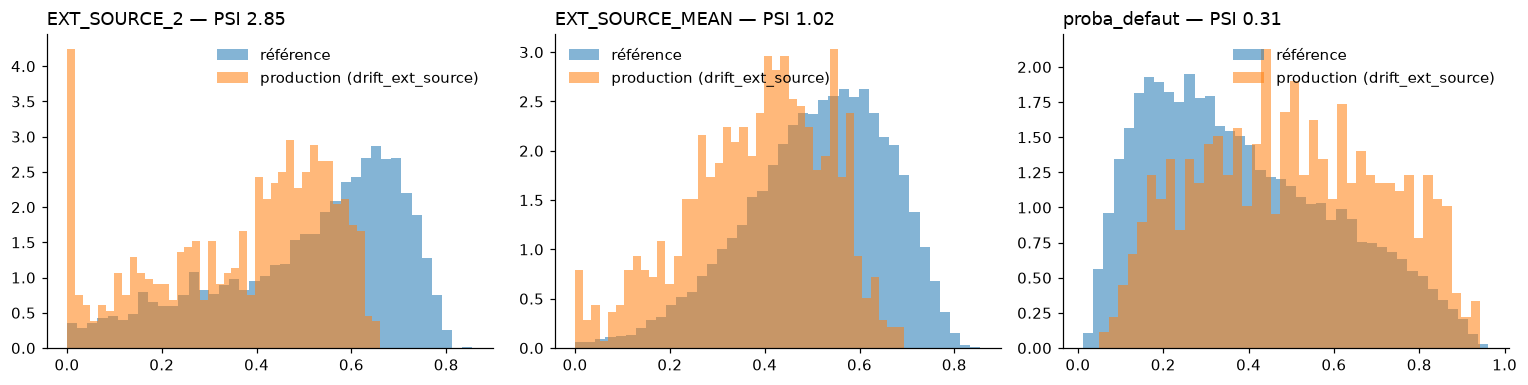

In [5]:
s = "drift_ext_source" if "drift_ext_source" in tables else scenarios[0]
t = tables[s]
display(t.head(12).round(4))
cur = expand_inputs(preds[preds["scenario"] == s])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col in zip(axes, ["EXT_SOURCE_2", "EXT_SOURCE_MEAN", "proba_defaut"]):
    ax.hist(reference[col].dropna(), bins=40, density=True, alpha=.55, label="référence")
    ax.hist(cur[col].dropna(), bins=40, density=True, alpha=.55, label=f"production ({s})")
    ax.set_title(f"{col} — PSI {t.set_index('colonne').loc[col, 'psi']:.2f}", loc="left"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 2.1 Rapport Evidently (DataDriftPreset)

In [6]:
out = Path("docs/reports"); out.mkdir(parents=True, exist_ok=True)
snap = evidently_report(reference, cur, out_html=out / f"evidently_{s}.html")
res = snap.dict()["metrics"]
def is_drifted(m):  # Evidently : p-value < seuil pour les tests statistiques, distance > seuil sinon (Wasserstein au-delà de 1 000 lignes)
    method, thr = m["config"]["method"], m["config"]["threshold"]
    return m["value"] < thr if "p_value" in method else m["value"] > thr
ev = pd.DataFrame([{"colonne": m["config"]["column"], "methode": m["config"]["method"], "valeur": m["value"], "seuil": m["config"]["threshold"], "derive": is_drifted(m)}
                   for m in res if m["metric_name"].startswith("ValueDrift")]).sort_values("valeur", ascending=False)
count = next(m for m in res if m["metric_name"].startswith("DriftedColumnsCount"))
print(f"Evidently ({s}) : {int(count['value']['count'])} colonnes en dérive sur {len(ev)} (part {count['value']['share']:.0%}) — rapport HTML : {out / f'evidently_{s}.html'}")
display(ev[ev["derive"]].round(3))
print("Accord PSI ≥ 0,25 / Evidently :", sorted(set(t[t['psi'] >= PSI_ALERT]['colonne']) & set(ev[ev['derive']]['colonne'])))

Evidently (drift_ext_source) : 7 colonnes en dérive sur 42 (part 17%) — rapport HTML : docs/reports/evidently_drift_ext_source.html


,colonne,methode,valeur,seuil,derive
32,EXT_SOURCE_MEAN,Wasserstein distance (normed),0.831,0.1,True
0,EXT_SOURCE_3,Wasserstein distance (normed),0.774,0.1,True
1,EXT_SOURCE_2,Wasserstein distance (normed),0.747,0.1,True
33,EXT_SOURCE_MIN,Wasserstein distance (normed),0.664,0.1,True
41,proba_defaut,Wasserstein distance (normed),0.525,0.1,True
8,CC_UTIL_MAX,Wasserstein distance (normed),0.131,0.1,True
27,LIVINGAREA_AVG,Wasserstein distance (normed),0.121,0.1,True


Accord PSI ≥ 0,25 / Evidently : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'proba_defaut']


### 2.2 Dérive des décisions : taux de refus et intervalle de confiance

,n,taux_refus,ic_bas,ic_haut,hors_reference
scenario,,,,,
(non marqué),300,0.000,0.000,0.013,True
drift_credit,800,0.320,0.289,0.353,False
drift_ext_source,800,0.528,0.493,0.562,True
drift_missing,800,0.334,0.302,0.367,False
drift_young,600,0.572,0.532,0.611,True
invalid,760,0.299,0.267,0.332,False
normal,2501,0.325,0.307,0.344,False


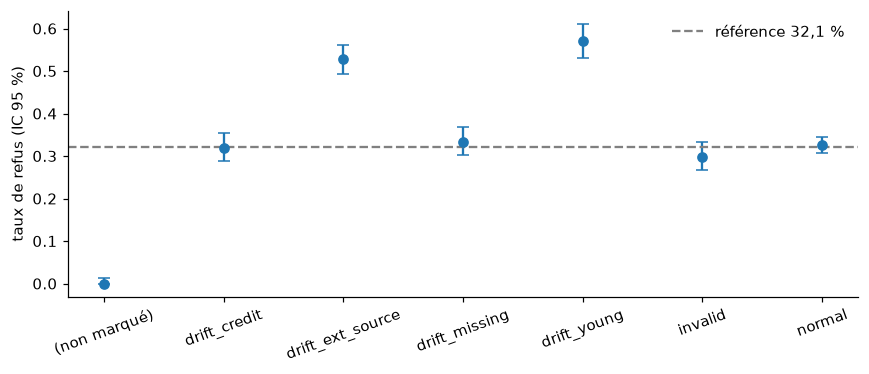

In [7]:
rows = []
for sc, g in preds.groupby("scenario"):
    n_ref = int((g["decision"] == "Refusé").sum()); p, lo, hi = refusal_rate_ci(n_ref, len(g))
    rows.append({"scenario": sc, "n": len(g), "taux_refus": p, "ic_bas": lo, "ic_haut": hi,
                 "hors_reference": not (lo <= ref_metrics["refusal_rate"] <= hi)})
refus = pd.DataFrame(rows).set_index("scenario")
display(refus.round(3))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(range(len(refus)), refus["taux_refus"], yerr=[refus["taux_refus"]-refus["ic_bas"], refus["ic_haut"]-refus["taux_refus"]], fmt="o", capsize=4)
ax.axhline(ref_metrics["refusal_rate"], ls="--", color="grey", label="référence 32,1 %")
ax.set_xticks(range(len(refus))); ax.set_xticklabels(refus.index, rotation=20); ax.set_ylabel("taux de refus (IC 95 %)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Performance : estimation sans labels vs labels différés

Le modèle XGBoost a été entraîné avec `scale_pos_weight ≈ 11` : ses probabilités brutes sont
**décalées vers le haut** (score moyen 0,385 pour un taux de défaut de 8 %). Avant d'estimer la
performance sans labels, on vérifie la calibration sur la référence et on ajuste un calibrateur
isotonique (utilisé uniquement pour l'estimation, jamais pour la décision).

ECE brut : 0.306   ECE après calibration isotonique : 0.000


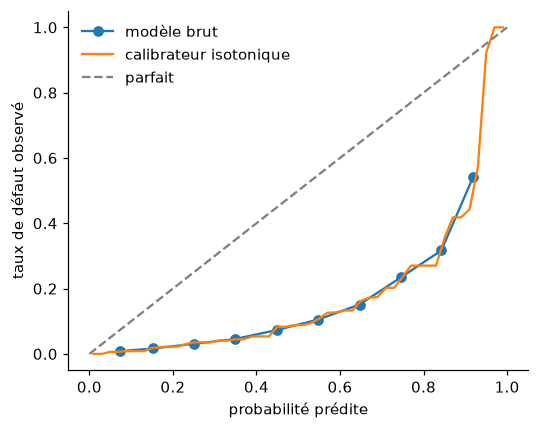

In [8]:
y_ref, p_ref = reference["TARGET"].to_numpy(), reference["proba_defaut"].to_numpy()
rt = reliability_table(y_ref, p_ref)
cal = fit_calibrator(y_ref, p_ref)
print(f"ECE brut : {expected_calibration_error(y_ref, p_ref):.3f}   ECE après calibration isotonique : {expected_calibration_error(y_ref, cal.predict(p_ref)):.3f}")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rt["proba_moyenne"], rt["taux_observe"], "o-", label="modèle brut")
grid = np.linspace(0.01, 0.99, 50); ax.plot(grid, cal.predict(grid), "-", label="calibrateur isotonique")
ax.plot([0, 1], [0, 1], "--", color="grey", label="parfait"); ax.set_xlabel("probabilité prédite"); ax.set_ylabel("taux de défaut observé"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [9]:
rows = []
for sc, g in preds.groupby("scenario"):
    exp = expected_metrics(g["proba_defaut"].to_numpy(), THRESHOLD, calibrator=cal)
    lab = g[g["target"].notna()]
    real = realized_metrics(lab["target"].to_numpy(), lab["proba_defaut"].to_numpy(), THRESHOLD) if len(lab) >= 50 else {}
    rows.append({"scenario": sc, "n": len(g), "n_labels": len(lab), "cout_attendu": exp["cout_attendu"], "cout_realise": real.get("cout"),
                 "auc_attendue": exp["auc_attendue"], "auc_realisee": real.get("auc"), "rappel_realise": real.get("rappel"),
                 "defaut_attendu": exp["taux_defaut_attendu"], "defaut_reel": real.get("taux_defaut")})
perf = pd.DataFrame(rows).set_index("scenario")
display(perf.round(3))
print(f"Référence P6 : coût {ref_metrics['business_cost']:.3f}, AUC {ref_metrics['auc']:.3f}, défaut {ref_metrics['default_rate']:.1%}")

,n,n_labels,cout_attendu,cout_realise,auc_attendue,auc_realisee,rappel_realise,defaut_attendu,defaut_reel
scenario,,,,,,,,,
(non marqué),300,0,0.217,NaN,0.500,NaN,NaN,0.022,NaN
drift_credit,800,800,0.495,0.391,0.771,0.848,0.811,0.077,0.066
drift_ext_source,800,800,0.622,0.516,0.757,0.844,0.925,0.120,0.066
drift_missing,800,800,0.518,0.432,0.764,0.820,0.774,0.080,0.066
drift_young,600,600,0.635,0.560,0.736,0.867,0.917,0.118,0.140
invalid,760,760,0.481,0.362,0.779,0.853,0.824,0.077,0.067
normal,2501,2500,0.494,0.452,0.783,0.822,0.758,0.081,0.076


Référence P6 : coût 0.501, AUC 0.778, défaut 8.1%


**Lecture.** Sur `normal`, l'estimation sans labels et les métriques réalisées concordent avec la
référence (coût ≈ 0,50, AUC ≈ 0,78). Sur `drift_ext_source`, l'estimation *attend* une population plus
risquée (coût attendu ↑) alors que les labels réels sont ceux des clients d'origine : le modèle
**sur-refuse** des bons clients (coût réalisé ↑ par les faux positifs, rappel ↑). C'est exactement le
signal à remonter : une dérive des entrées dégrade le coût métier même si l'AUC se maintient.
L'écart entre attendu et réalisé mesure la part de *concept drift* (relation entrées → défaut) que
l'estimation sans labels ne peut pas voir : d'où l'importance de collecter les labels différés.

## 4. Calibrage du seuil de décision

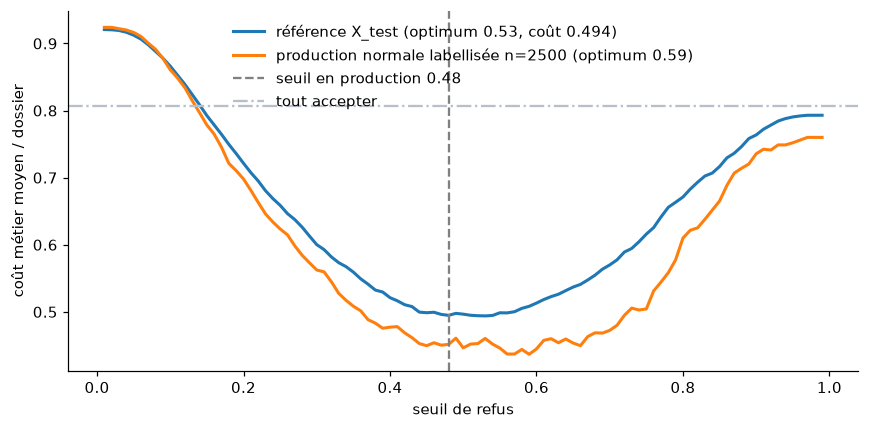

Plateau de coût (≤ +1 % du minimum) : seuils 0.45 → 0.56. Le seuil 0,48 (CV du P6) est dans le plateau : pas de re-calibrage nécessaire.


,seuil_optimal
poids FN,
5,0.67
8,0.57
10,0.53
12,0.44
15,0.44
20,0.38


In [10]:
curve_ref = cost_curve(y_ref, p_ref)
t_ref, c_ref = optimal_threshold(curve_ref)
lab = preds[preds["target"].notna() & (preds["scenario"] == "normal")]
curve_prod = cost_curve(lab["target"].to_numpy(), lab["proba_defaut"].to_numpy()) if len(lab) >= 200 else None
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_ref["seuil"], curve_ref["cout"], lw=2, label=f"référence X_test (optimum {t_ref:.2f}, coût {c_ref:.3f})")
if curve_prod is not None:
    t_p, c_p = optimal_threshold(curve_prod); ax.plot(curve_prod["seuil"], curve_prod["cout"], lw=2, label=f"production normale labellisée n={len(lab)} (optimum {t_p:.2f})")
ax.axvline(THRESHOLD, ls="--", color="grey", label=f"seuil en production {THRESHOLD:.2f}")
ax.axhline(ref_metrics["business_cost_accept_all"], ls="-.", color="#b9bfc9", label="tout accepter")
ax.set_xlabel("seuil de refus"); ax.set_ylabel("coût métier moyen / dossier"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
zone = curve_ref[(curve_ref["cout"] <= c_ref * 1.01)]
print(f"Plateau de coût (≤ +1 % du minimum) : seuils {zone['seuil'].min():.2f} → {zone['seuil'].max():.2f}. Le seuil 0,48 (CV du P6) est dans le plateau : pas de re-calibrage nécessaire.")
sens = pd.DataFrame({w: {"seuil_optimal": optimal_threshold(cost_curve(y_ref, p_ref, cost_fn=w))[0]} for w in (5, 8, 10, 12, 15, 20)}).T
sens.index.name = "poids FN"; display(sens)

## 5. Aspects opérationnels : latence et erreurs

In [11]:
lat = preds["latency_total_ms"]
print(f"Latence serveur (features + inférence, backend {preds['model_backend'].iloc[-1]}) : p50 {lat.quantile(.5):.2f} ms, p95 {lat.quantile(.95):.2f} ms, p99 {lat.quantile(.99):.2f} ms, max {lat.max():.1f} ms")
print(f"Erreurs API : {len(errors)} ({errors['error_type'].value_counts().to_dict() if len(errors) else {}})")
if len(errors):
    err = errors.copy(); err["champ"] = err["detail"].apply(lambda d: ".".join(map(str, d[0]["loc"][1:])) if d else None); err["type"] = err["detail"].apply(lambda d: d[0]["type"] if d else None)
    display(err.groupby(["champ", "type"]).size().rename("n").reset_index())

Latence serveur (features + inférence, backend xgb_native) : p50 0.30 ms, p95 0.70 ms, p99 1.45 ms, max 12.3 ms
Erreurs API : 42 ({'validation_error': 42})


,champ,type,n
0,AMT_CREDIT,float_type,13
1,AMT_CREDIT,greater_than,10
2,DAYS_BIRTH,less_than_equal,19


## 6. Synthèse et points de vigilance

1. **Détection** : PSI + KS avec seuils explicites détectent chaque dérive simulée sur les bonnes
   variables, sans faux positif sur le trafic normal (≥ 200 lignes requises). Evidently confirme.
2. **Impact métier** : la dérive des scores externes fait bondir le taux de refus (IC 95 % hors
   référence) et le coût métier réalisé ; une panne de fournisseur (`drift_missing`) est visible via
   le taux de NaN et `EXT_SOURCE_NB_NAN` avant même la dérive du score.
3. **Sans labels**, l'estimation CBPE suppose la calibration et l'absence de concept drift : elle
   sert d'alerte précoce, mais la **collecte des labels différés** reste indispensable pour mesurer
   le coût réel et re-calibrer le seuil.
4. **Seuil** : 0,48 est dans le plateau optimal ; il devra être revu si le poids FN/FP change ou si
   la courbe de coût en production se déplace.
5. **Maintenance** : automatiser ce notebook (job planifié, `make drift-report`) avec alerte si
   `dataset_drift` ou si le taux de refus sort de l'IC ; déclencher le ré-entraînement
   (`scripts/retrain_stub.py`) quand le coût réalisé dépasse la référence de plus de 10 % sur une
   fenêtre glissante avec assez de labels.
6. **Stockage / RGPD** : entrées complètes échantillonnées (25 %) et purgeables ; pas d'identifiant
   personnel dans les journaux, uniquement `client_ref` technique.